# Behavioural Signature Classification Prototype
This notebook loads a few stocks, calculates the complete suite of structural derivatives (Slope, ROC, SD, SE, R-Squared, Relative Position) using a 21-day Micro and 100-day Macro lookback, and plots them over a 3-month period.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os, glob
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
MICRO_LOOKBACK = 21
MACRO_LOOKBACK = 100
PLOT_START = '2023-01-01'
PLOT_END = '2023-03-31'

WARMUP_DAYS = MACRO_LOOKBACK + 10

In [2]:
# --- MATH FUNCTIONS ---
def calc_rolling_regression_features(series, window):
    slopes = np.full(len(series), np.nan)
    r_squared = np.full(len(series), np.nan)
    std_errors = np.full(len(series), np.nan)
    reg_line_values = np.full(len(series), np.nan)
    
    x = np.arange(window)
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        mean_y = np.mean(y)
        
        slope, intercept, r_val, p_val, std_err = linregress(x, y)
        
        # Annualized Normalized Slope %
        slopes[i] = (slope / mean_y) * 252 * 100  
        r_squared[i] = r_val**2
        # Normalized SE %
        std_errors[i] = (std_err / mean_y) * 100 
        
        # The exact value of the regression line on 'today' (the end of the window)
        reg_line_values[i] = (slope * (window - 1)) + intercept
        
    return pd.Series(slopes, index=series.index), \
           pd.Series(r_squared, index=series.index), \
           pd.Series(std_errors, index=series.index), \
           pd.Series(reg_line_values, index=series.index)

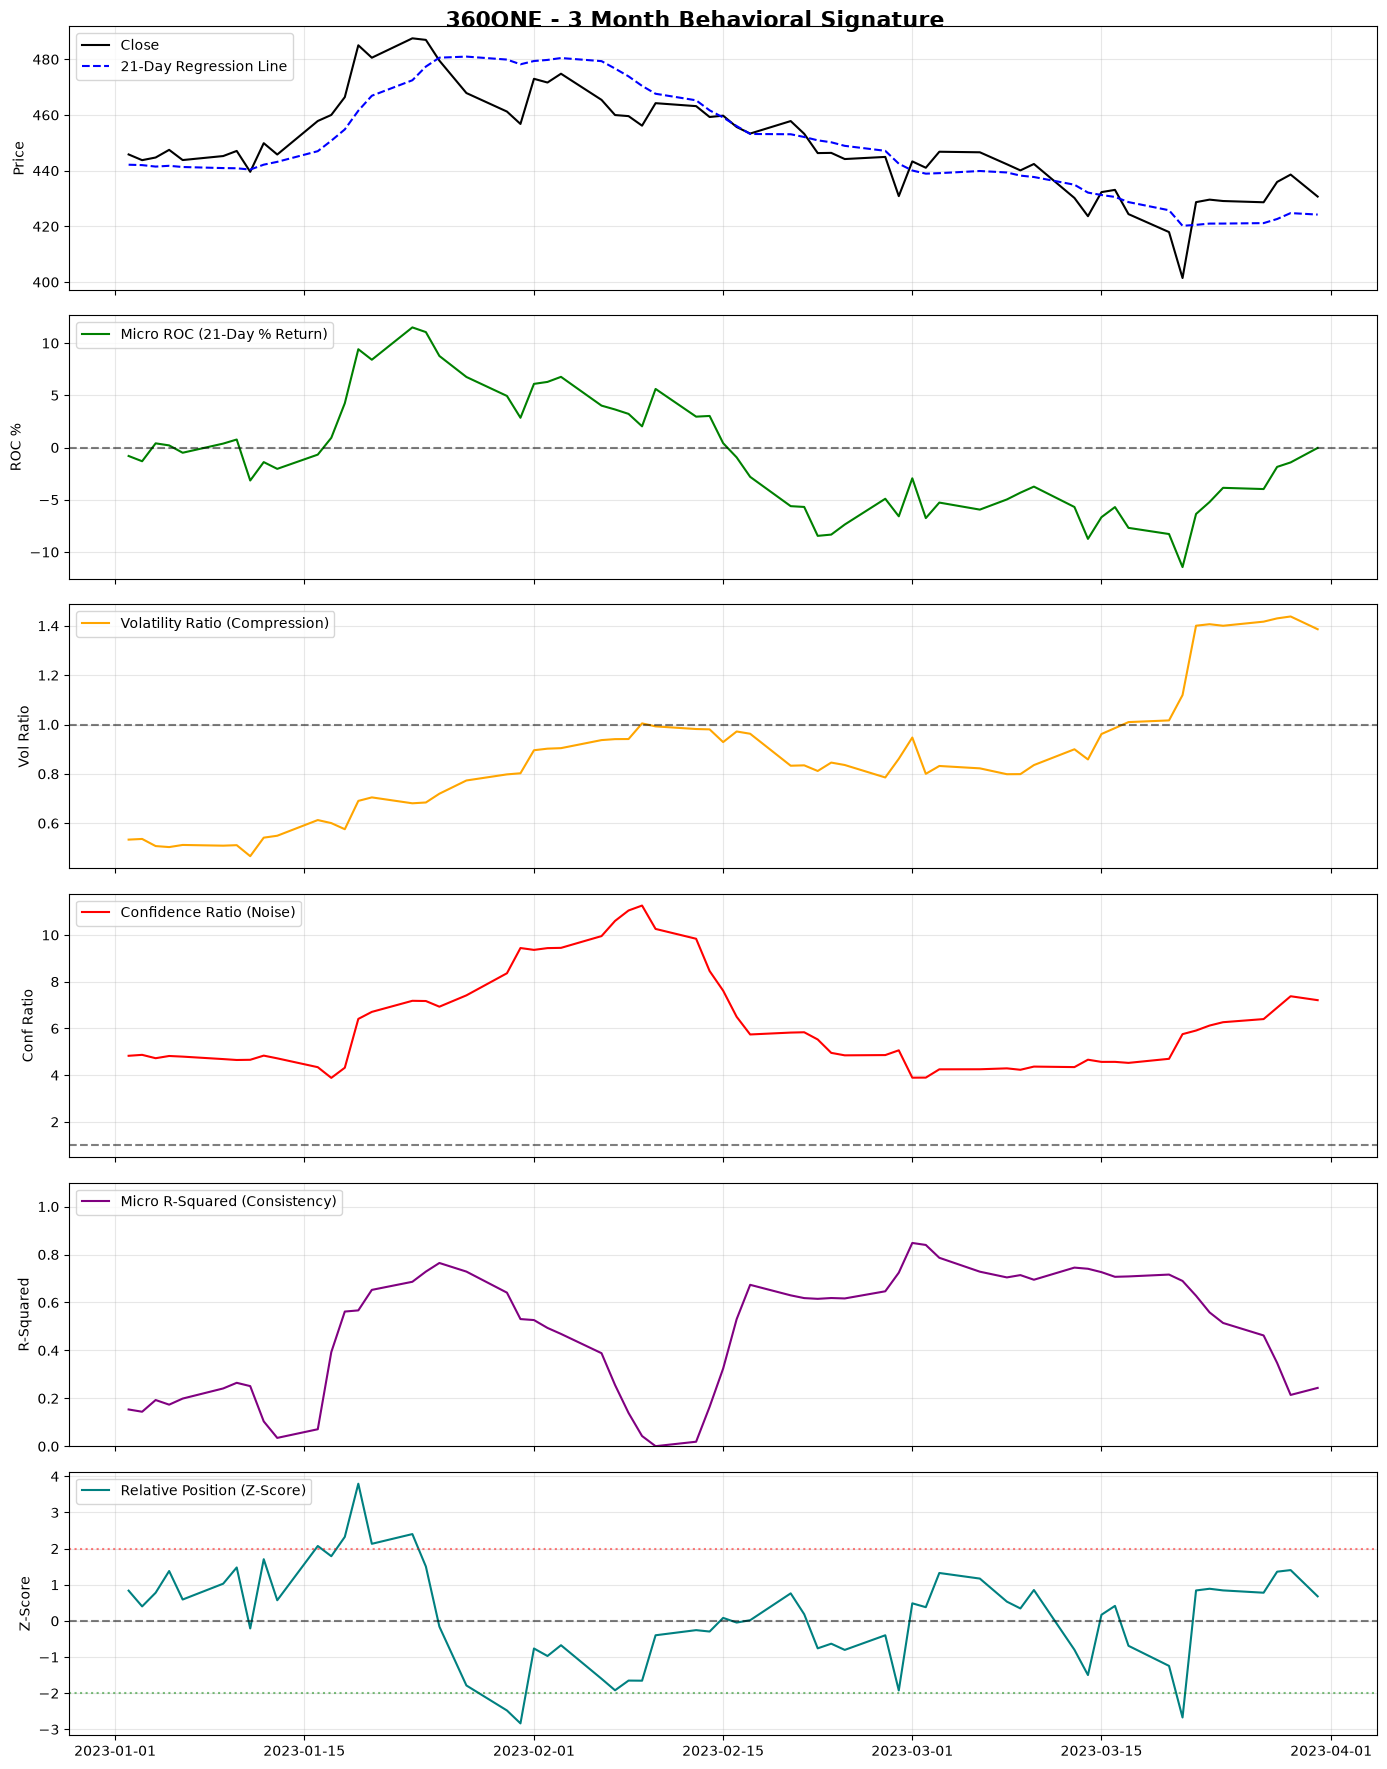

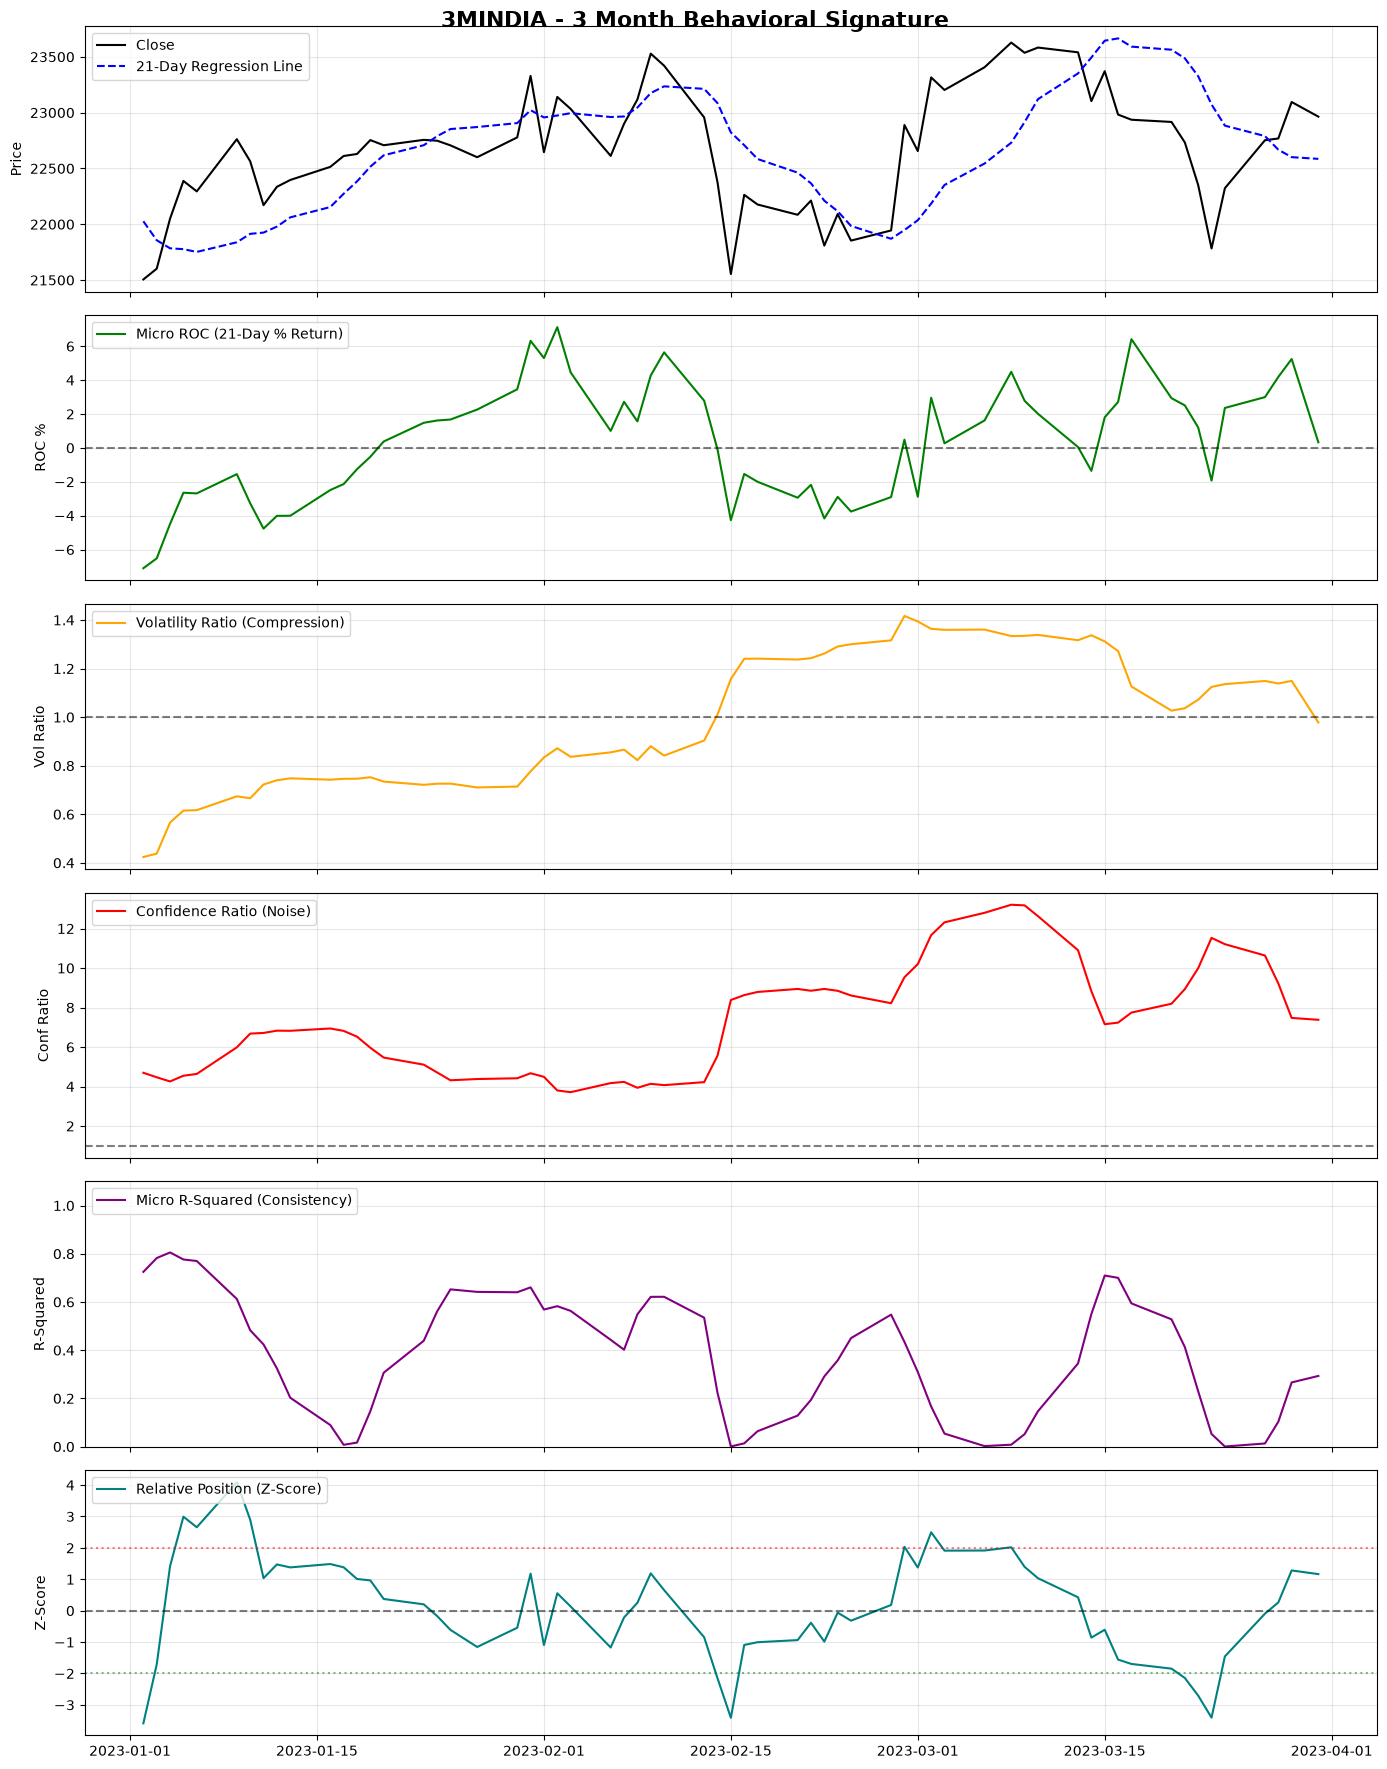

In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:3]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # 1. Linear Regression Features
    df['micro_slope'], df['micro_r2'], df['micro_se'], df['micro_reg_val'] = calc_rolling_regression_features(df['Close'], MICRO_LOOKBACK)
    df['macro_slope'], df['macro_r2'], df['macro_se'], _ = calc_rolling_regression_features(df['Close'], MACRO_LOOKBACK)
    
    # 2. Standard Deviation
    df['micro_sd'] = df['Close'].pct_change().rolling(MICRO_LOOKBACK).std() * np.sqrt(252) * 100
    df['macro_sd'] = df['Close'].pct_change().rolling(MACRO_LOOKBACK).std() * np.sqrt(252) * 100
    
    # 3. Rate of Change (Momentum/Velocity)
    df['micro_ROC'] = df['Close'].pct_change(periods=MICRO_LOOKBACK) * 100
    
    # 4. Relative Position (Z-Score from Regression Line)
    # Using daily raw SD for the Z-score calculation
    daily_sd = df['Close'].pct_change().rolling(MICRO_LOOKBACK).std() * df['micro_reg_val']
    df['price_vs_micro_regression_Z'] = (df['Close'] - df['micro_reg_val']) / daily_sd
    
    # Ratios
    df['volatility_ratio'] = df['micro_sd'] / df['macro_sd']
    df['confidence_ratio'] = df['micro_se'] / df['macro_se']
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
    fig.suptitle(f"{stock_name} - 3 Month Behavioral Signature", fontsize=16, weight='bold')
    
    # Plot 1: Price & Regression Line
    axes[0].plot(plot_df['Date'], plot_df['Close'], color='black', label='Close')
    axes[0].plot(plot_df['Date'], plot_df['micro_reg_val'], color='blue', linestyle='--', label='21-Day Regression Line')
    axes[0].set_ylabel("Price")
    axes[0].legend(loc='upper left')
    axes[0].grid(alpha=0.3)
    
    # Plot 2: ROC (Momentum)
    axes[1].plot(plot_df['Date'], plot_df['micro_ROC'], color='green', label='Micro ROC (21-Day % Return)')
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[1].set_ylabel("ROC %")
    axes[1].legend(loc='upper left')
    axes[1].grid(alpha=0.3)
    
    # Plot 3: Volatility Ratio
    axes[2].plot(plot_df['Date'], plot_df['volatility_ratio'], color='orange', label='Volatility Ratio (Compression)')
    axes[2].axhline(1.0, color='black', linestyle='--', alpha=0.5)
    axes[2].set_ylabel("Vol Ratio")
    axes[2].legend(loc='upper left')
    axes[2].grid(alpha=0.3)
    
    # Plot 4: Confidence Ratio (Noise)
    axes[3].plot(plot_df['Date'], plot_df['confidence_ratio'], color='red', label='Confidence Ratio (Noise)')
    axes[3].axhline(1.0, color='black', linestyle='--', alpha=0.5)
    axes[3].set_ylabel("Conf Ratio")
    axes[3].legend(loc='upper left')
    axes[3].grid(alpha=0.3)
    
    # Plot 5: R-Squared (Consistency)
    axes[4].plot(plot_df['Date'], plot_df['micro_r2'], color='purple', label='Micro R-Squared (Consistency)')
    axes[4].set_ylim(0, 1.1)
    axes[4].set_ylabel("R-Squared")
    axes[4].legend(loc='upper left')
    axes[4].grid(alpha=0.3)
    
    # Plot 6: Relative Position (Z-Score)
    axes[5].plot(plot_df['Date'], plot_df['price_vs_micro_regression_Z'], color='teal', label='Relative Position (Z-Score)')
    axes[5].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[5].axhline(2, color='red', linestyle=':', alpha=0.5)
    axes[5].axhline(-2, color='green', linestyle=':', alpha=0.5)
    axes[5].set_ylabel("Z-Score")
    axes[5].legend(loc='upper left')
    axes[5].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
